# DTEx212. Single Particle Tracking

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx212_single_particle_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

In [ ]:
# !pip install opencv-python  # Uncomment if needed.

In this example, you train a convolutional neural network with a dense top using simulation data, and then apply it to experimental videos of an optically trapped particle.

In [2]:
import deeptrack as dt
import deeplay as dl
import numpy as np
import matplotlib.pyplot as plt
import torch

## 1. Loading the Experimental Videos

Start by downloading the `particle_dataset`. This folder contains two videos of an optically trapped particle. One video is acquired with very low noise (`low_noise.avi`), while the other has very high noise (`high_noise.avi`).

In [3]:
import os

if not os.path.exists("particle_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/particle_dataset")

Next, you define a function that loads a video.

In [4]:
import cv2


def load_video(path, frames_to_load, image_size):
    """Load video."""
    video = cv2.VideoCapture(path)

    data = []
    for _ in range(frames_to_load):
        _, frame = video.read()
        frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) / 255
        frame = cv2.resize(frame, (image_size, image_size))
        data.append(frame)

    return np.array(data)

You then use this function to load the low-noise and high-noise videos.

In [5]:
image_size = 51
video_low_noise = load_video(
    os.path.join("particle_dataset", "low_noise.avi"),
    frames_to_load=100,
    image_size=image_size,
)
video_high_noise = load_video(
    os.path.join("particle_dataset", "high_noise.avi"),
    frames_to_load=100,
    image_size=image_size,
)

Finally, you plot a few frames from each video.

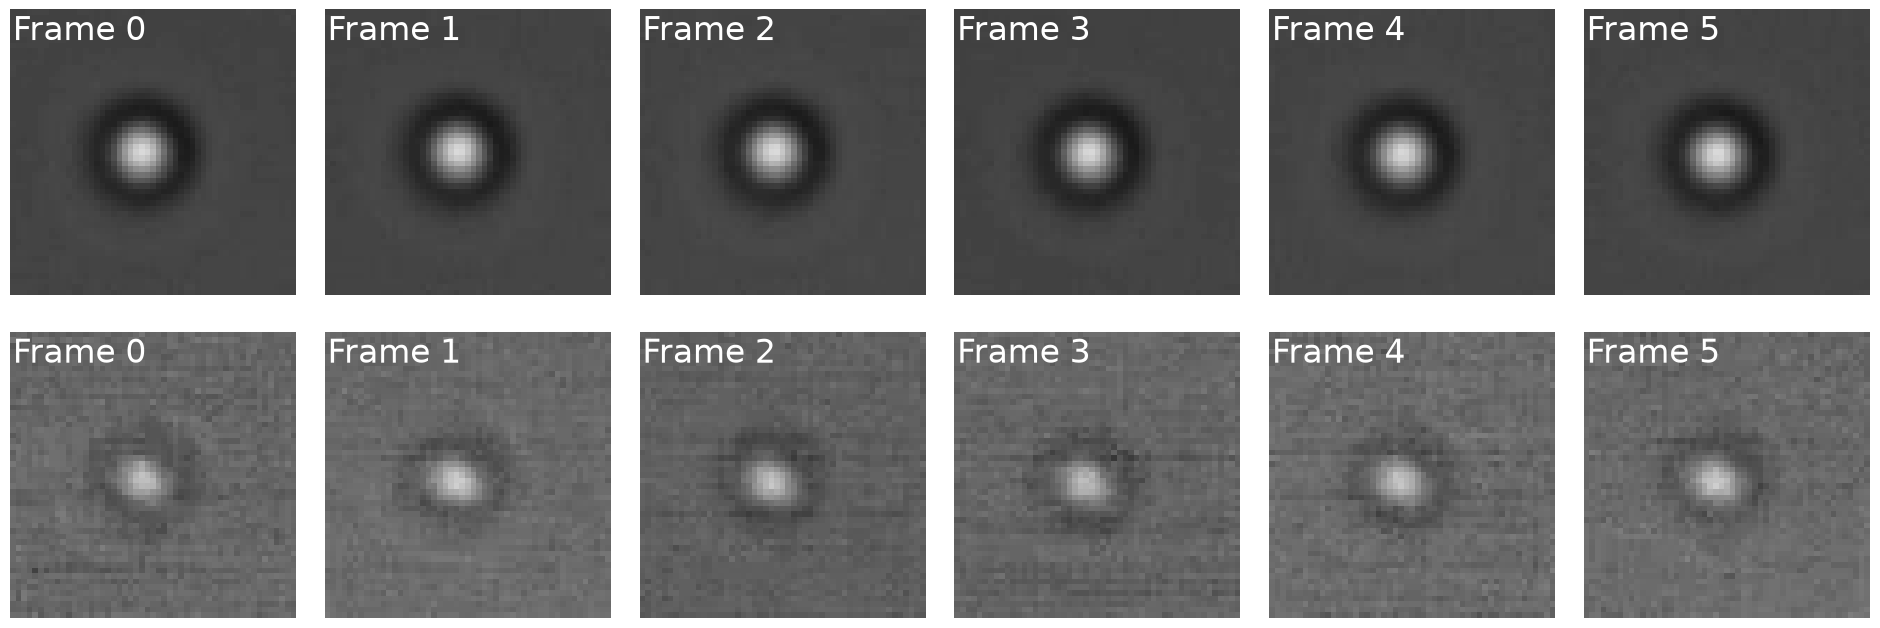

In [6]:
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
for i in range(6):
    axs[0, i].imshow(video_low_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[0, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[0, i].axis("off")

    axs[1, i].imshow(video_high_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[1, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[1, i].axis("off")
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## 2. Defining the Simulation Dataset

### 2.1. Defining the Training Set

The training set consists of simulated images of 51 by 51 pixels, the same size as the experimental frames, each containing a single particle. You simulate the particle as a sphere with a radius between 500 nm and 600 nm and a refractive index between 1.37 and 1.42. Its position in the camera plane is drawn uniformly within 5 pixels of the image center, and its position along the axis normal to the camera plane is drawn uniformly between -1 and 1 pixel.

In [7]:
particle = dt.scatterers.MieSphere(
    position=lambda: np.random.uniform(
        image_size / 2 - 5, image_size / 2 + 5, 2
    )
    * dt.units.pixel,
    z=lambda: np.random.uniform(-1, 1) * dt.units.pixel,
    radius=lambda: np.random.uniform(500, 600) * 1e-9,
    refractive_index=lambda: np.random.uniform(1.37, 1.42),
    position_unit="pixel",
)

You image the particle with a brightfield microscope with a numerical aperture of 0.8, a magnification of 15, and an illuminating laser wavelength of 630 nm.

In [8]:
brightfield_microscope = dt.Brightfield(
    NA=0.8,
    resolution=1e-6,
    magnification=15,
    wavelength=630 * 1e-9,
    refractive_index_medium=1.33,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, image_size, image_size),
)

dataset = brightfield_microscope(particle)

### 2.2. Visualizing the Dataset

You resolve and show six images, each with a green circle marking the particle position. You read the position directly from the particle with `particle.position()`.

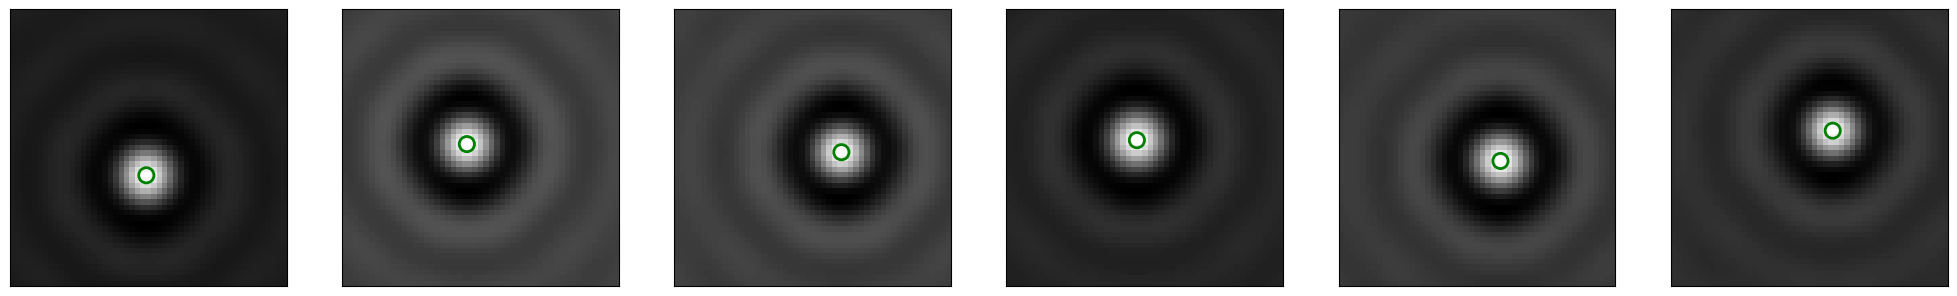

In [9]:
number_of_images = 6

fig, axs = plt.subplots(1, number_of_images, figsize=(25, 8))
for i, ax in enumerate(axs.flatten()):

    dataset.update()
    image_of_particle = dataset.resolve()

    position_of_particle = particle.position()

    ax.imshow(image_of_particle[..., 0], cmap="gray")
    ax.scatter(
        position_of_particle[1],
        position_of_particle[0],
        s=120,
        facecolors="none",
        edgecolors="g",
        linewidth=2,
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### 2.3. Augmenting the Dataset

Simulating Mie particles is slow, so you augment each simulated image to get several training examples from it. Here you flip and mirror the image.

In [10]:
flip_lr = dt.FlipLR(p=0.5)
flip_ud = dt.FlipUD(p=0.5)
flip_diagonal = dt.FlipDiagonal(p=0.5)

augmented_dataset = (
    dt.Reuse(dataset, uses=8) >> flip_lr >> flip_ud >> flip_diagonal
)

You add noise after augmentation, so that the augmented images differ more from one another. You apply an illumination gradient, Poisson noise with a signal-to-noise ratio between 5 and 100, and a final normalization.

In [11]:
gradient = dt.IlluminationGradient(
    gradient=lambda: np.random.randn(2) * 1e-4,
)

noise = dt.Poisson(
    min_snr=5,
    max_snr=100,
    snr=lambda min_snr, max_snr: min_snr
    + np.random.rand() * (max_snr - min_snr),
    background=1,
)

normalization = dt.NormalizeMinMax(
    lambda: np.random.rand() * 0.2,
    lambda: 0.8 + np.random.rand() * 0.2,
)

data_pipeline = augmented_dataset >> gradient >> noise >> normalization

To get the position of the particle, you use `particle.position` to create a pipeline for the position. Then you create a combined pipeline that holds both the image of the particle and its corresponding position.

In [12]:
pos_pipeline = particle.position

combined_pip = data_pipeline & pos_pipeline

You resolve and show six images, each with a green circle marking the particle position. Since `particle.position` gives the position before the flips, you reapply the same flips to it here so the circle lands on the particle.

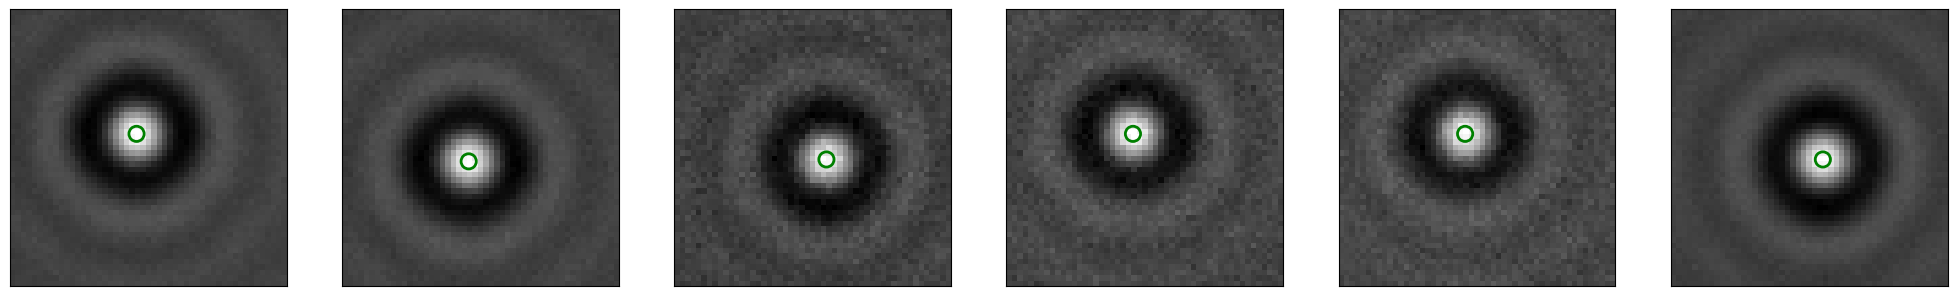

In [13]:
number_of_images = 6

fig, axs = plt.subplots(1, number_of_images, figsize=(25, 8))
for i, ax in enumerate(axs.flatten()):

    combined_pip.update()
    image_of_particle, raw_position = combined_pip.resolve()

    position_of_particle = raw_position.copy()
    if flip_lr.augment():
        position_of_particle[1] = image_size - 1 - position_of_particle[1]
    if flip_ud.augment():
        position_of_particle[0] = image_size - 1 - position_of_particle[0]
    if flip_diagonal.augment():
        position_of_particle = position_of_particle[::-1]

    ax.imshow(image_of_particle[..., 0], cmap="gray")
    ax.scatter(
        position_of_particle[1],
        position_of_particle[0],
        s=120,
        facecolors="none",
        edgecolors="g",
        linewidth=2,
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## 3. Defining the Network

The network is a convolutional neural network with a dense top. You first define its architecture.

In [14]:
cnn = dl.Sequential(
    dl.ConvolutionalNeuralNetwork(
        in_channels=1,
        hidden_channels=[16, 32],
        out_channels=64,
        pool=torch.nn.MaxPool2d(kernel_size=2),
        out_activation=torch.nn.ReLU,
    ),
    dl.Layer(torch.nn.MaxPool2d, kernel_size=2),
    dl.Layer(torch.nn.Flatten),
    dl.MultiLayerPerceptron(
        in_features=6 * 6 * 64,
        hidden_features=[32, 32],
        out_features=2,
        out_activation=torch.nn.Identity,
    ),
)

print(cnn)

Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (1): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Layer[Conv2d](in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (2): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Layer[Conv2d](in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
    )
  )
  (1): Layer[MaxPool2d](kernel_size=2)
  (2): Layer[Flatten]()
  (3): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Layer[Linear](in_features=2304, out_features=32, bias=True)
        (activa

Then, you compile it for a regression task, defining the loss function, the optimizer, and the error metric.

In [15]:
from torchmetrics import MeanAbsoluteError as MAE

cnn_regressor_template = dl.Regressor(
    model=cnn,
    loss=torch.nn.MSELoss(),
    optimizer=dl.Adam(),
    metrics=[MAE()],
)
cnn_sim_regressor = cnn_regressor_template.create()

print(cnn_sim_regressor)

Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64,

## 4. Training the Network

First, you define a custom dataset that generates the simulated images and their position labels.

In `__getitem__`, you turn each image and position into tensors and rescale the position with `self.positions[idx] / im.shape[-1] - 0.5`. Dividing by the image size and subtracting 0.5 maps the position from pixels to the range -0.5 to 0.5. Networks train more easily when the targets are small and centered on zero, so this rescaling helps the training converge.

In [16]:
class SimulatedDataset(torch.utils.data.Dataset):
    """Dataset with simulated particles."""

    def __init__(self, pipeline, data_size):
        """Initialize simulated dataset."""
        images, positions = [], []
        for _ in range(data_size):
            image, raw_position = pipeline.update().resolve()

            position = raw_position.copy()
            if flip_lr.augment():
                position[1] = image_size - 1 - position[1]
            if flip_ud.augment():
                position[0] = image_size - 1 - position[0]
            if flip_diagonal.augment():
                position = position[::-1]

            images.append(image)
            positions.append(position[[1, 0]])
        self.images = np.array(images)
        self.positions = np.array(positions)

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next simulated image and position."""
        im = torch.tensor(self.images[idx]).float().permute(2, 0, 1)
        pos = torch.tensor(self.positions[idx] / im.shape[-1] - 0.5).float()
        return [im, pos]

Then, you use it to create the training and test data loaders.

In [17]:
train_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=combined_pip, data_size=3000),
    batch_size=32,
)
test_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=combined_pip, data_size=1000),
    batch_size=32,
)

Finally, you train the neural network regressor on the simulated data.

In [18]:
cnn_sim_trainer = dl.Trainer(max_epochs=50, accelerator="auto")
cnn_sim_trainer.fit(cnn_sim_regressor, train_sim_dataloader)

/home/guillem/miniforge3/envs/deeptrack2/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/guillem/miniforge3/envs/deeptrack2/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │ 98.2 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 98.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 98.2 K                                                                                               
Total estimated model params size (MB): 0.393                                                                      
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/guillem/miniforge3/envs/deeptrack2/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/guillem/miniforge3/envs/deeptrack2/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

## 5. Evaluating the Network

### 5.1. Testing on Simulated Data

You calculate the mean absolute error (MAE) on the training set, expressed in pixels.

In [19]:
train_sim_results = cnn_sim_trainer.test(
    cnn_sim_regressor, train_sim_dataloader
)
MAE_sim = train_sim_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE) for train dataset: {MAE_sim:.3f} pixels")

/home/guillem/miniforge3/envs/deeptrack2/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.0014776213793084025    │
│       test_loss_epoch       │    3.829703928204253e-06    │
└─────────────────────────────┴─────────────────────────────┘

Mean pixel error (MAE) for train dataset: 0.075 pixels


Then you do the same on the test set.

In [20]:
test_sim_results = cnn_sim_trainer.test(cnn_sim_regressor, test_sim_dataloader)
MAE_sim = test_sim_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE) for test dataset: {MAE_sim:.3f} pixels")

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.0016120889922603965    │
│       test_loss_epoch       │    4.514445208769757e-06    │
└─────────────────────────────┴─────────────────────────────┘

Mean pixel error (MAE) for test dataset: 0.082 pixels


### 5.2. Prediction vs Actual

You can also plot each predicted coordinate against its ground-truth value for the training set.

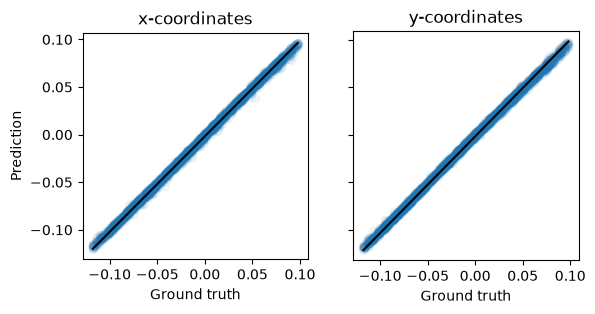

In [21]:
preds, gts = [], []
for image, position in iter(train_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

fig, axs = plt.subplots(1, 2)
for i, ax, coordinate in zip([0, 1], axs, ["x", "y"]):
    gt, pred = gts[:][:, i], preds[:][:, i]
    ax.scatter(gt, pred, alpha=0.05)
    ax.plot([np.min(gt), np.max(gt)], [np.min(pred), np.max(pred)], c="k")
    ax.set_title(f"{coordinate}-coordinates")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.set_aspect("equal")
    ax.label_outer()
plt.show()

Then you do the same for the test set.

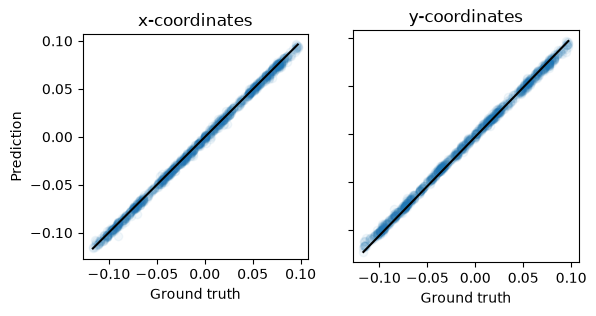

In [22]:
preds, gts = [], []
for image, position in iter(test_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

fig, axs = plt.subplots(1, 2)
for i, ax, coordinate in zip([0, 1], axs, ["x", "y"]):
    gt, pred = gts[:][:, i], preds[:][:, i]
    ax.scatter(gt, pred, alpha=0.05)
    ax.plot([np.min(gt), np.max(gt)], [np.min(pred), np.max(pred)], c="k")
    ax.set_title(f"{coordinate}-coordinates")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.set_aspect("equal")
    ax.label_outer()
plt.show()

### 5.3. Prediction vs Property Value

You can also look at how the pixel error depends on the properties of the simulated particle.

For a fresh set of simulated particles, you record each particle's properties and measure the network's pixel error on that same image. You read each property directly from the object that defines it, by calling `particle.position()`, `noise.snr()`, and so on, right after resolving the image.

In [23]:
properties = ["position", "z", "refractive_index", "snr", "gradient"]

property_values = []
preds, gts = [], []

for _ in range(1000):
    image, raw_position = combined_pip.update().resolve()

    property_values.append(
        {
            "position": particle.position(),
            "z": particle.z().magnitude,
            "refractive_index": particle.refractive_index(),
            "snr": noise.snr(),
            "gradient": gradient.gradient(),
        }
    )

    position = raw_position.copy()
    if flip_lr.augment():
        position[1] = image_size - 1 - position[1]
    if flip_ud.augment():
        position[0] = image_size - 1 - position[0]
    if flip_diagonal.augment():
        position = position[::-1]

    im = torch.tensor(image).float().permute(2, 0, 1)
    preds.append(cnn_sim_regressor(im.unsqueeze(0))[0].detach().numpy())
    gts.append(position[[1, 0]] / image_size - 0.5)

preds, gts = np.array(preds), np.array(gts)
test_error = np.mean(np.abs(preds - gts), axis=-1) * image_size

You then define a function that scatters the pixel error against a chosen property.

In [24]:
def error_vs_property(property_name):
    values = np.array([sample[property_name] for sample in property_values])
    if values.ndim == 1:
        values = np.expand_dims(values, axis=-1)

    for col in range(values.shape[1]):
        plt.subplot(1, values.shape[1], col + 1)
        plt.scatter(values[:, col], test_error, alpha=0.1)
        plt.yscale("log")
        plt.ylabel("Pixel error")
        plt.xlabel("{0}[{1}]".format(property_name, col))
    plt.show()

You first look at how the error varies with the position in the camera plane and along the axis normal to it (z).

/tmp/ipykernel_274952/2082567267.py:2: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  values = np.array([sample[property_name] for sample in property_values])


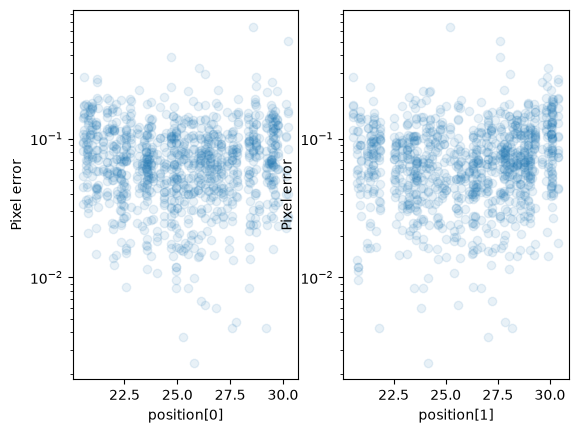

In [25]:
error_vs_property("position")

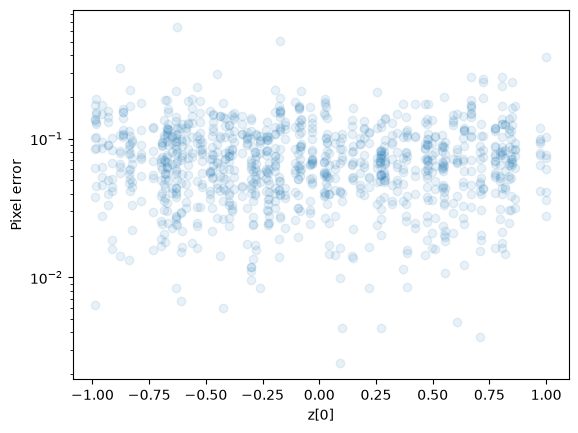

In [26]:
error_vs_property("z")

Then you look at the signal-to-noise ratio (snr).

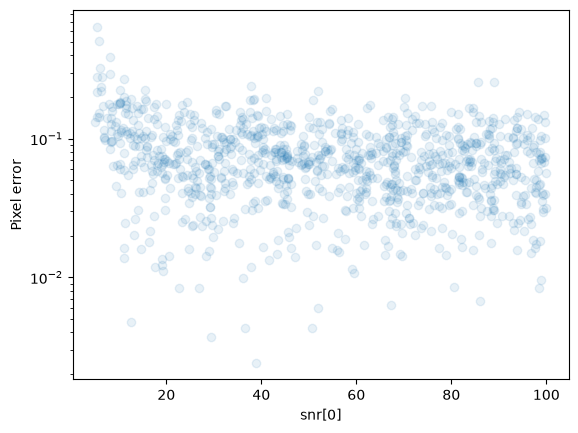

In [27]:
error_vs_property("snr")

Then the illumination gradient.

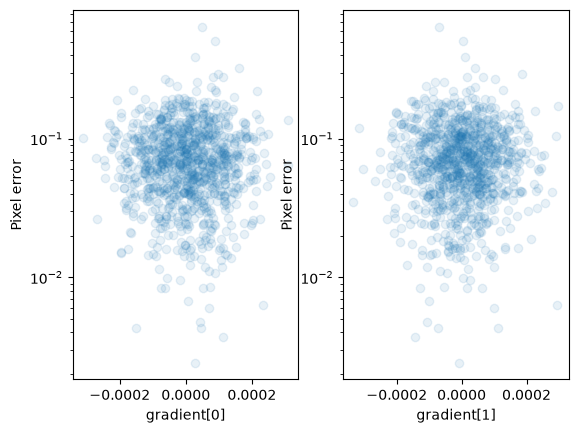

In [28]:
error_vs_property("gradient")

And finally the refractive index.

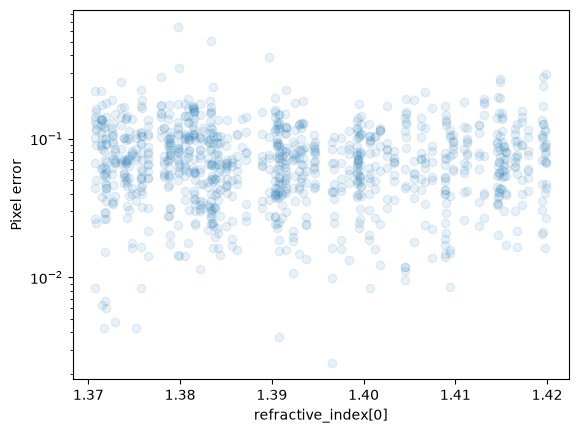

In [29]:
error_vs_property("refractive_index")

### 5.4. Experimental Data

Finally, you apply the trained model to real data: two experimental videos, one with low noise and one with high noise. The network was trained only on simulated images, so this lets you see how well it carries over to real frames.

First, you define a custom dataset for the experimental videos.

In [30]:
class ExperimentalDataset(torch.utils.data.Dataset):
    """Experimental dataset."""

    def __init__(self, data_images):
        """Load experimental images"""
        self.images = data_images

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next image."""
        im = torch.tensor(self.images[idx, np.newaxis, :, :]).float()
        return im

Then, you use it to create the low-noise and high-noise data loaders.

In [31]:
video_low_noise_dataloader = dl.DataLoader(
    ExperimentalDataset(data_images=video_low_noise),
    batch_size=32,
)
video_high_noise_dataloader = dl.DataLoader(
    ExperimentalDataset(data_images=video_high_noise),
    batch_size=32,
)

You use the trained model to predict the particle position in the low-noise video.

In [32]:
preds = []
for image in iter(video_low_noise_dataloader):
    preds.append(cnn_sim_regressor(image))
preds = torch.cat(preds, dim=0).detach().numpy()
preds = preds * image_size + image_size / 2

Then you display the result as an animation.

In [33]:
%matplotlib notebook

import matplotlib.animation as animation
from IPython.display import HTML

fig, ax1 = plt.subplots()

ax1.imshow(video_low_noise[0], cmap="gray")
(point,) = ax1.plot(preds[0:1, 0], preds[0:1, 1], c="r", marker="o")


def init():
    ax1.imshow(video_low_noise[0], cmap="gray")
    point.set_data(preds[0:1, 0], preds[0:1, 1])
    return point


def animate(idx):
    ax1.imshow(video_low_noise[idx], cmap="gray")
    point.set_data(preds[idx : idx + 1, 0], preds[idx : idx + 1, 1])
    return point


ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=video_low_noise.shape[0],
    interval=50,
    blit=True,
)

HTML(ani.to_jshtml())

<IPython.core.display.Javascript object>

You then do the same for the high-noise video.

In [34]:
preds = []
for image in iter(video_high_noise_dataloader):
    preds.append(cnn_sim_regressor(image))
preds = torch.cat(preds, dim=0).detach().numpy()
preds = preds * image_size + image_size / 2

And display the result.

In [35]:
fig, ax1 = plt.subplots()

ax1.imshow(video_high_noise[0], cmap="gray")
(point,) = ax1.plot(preds[0:1, 0], preds[0:1, 1], c="r", marker="o")


def init():
    ax1.imshow(video_high_noise[0], cmap="gray")
    point.set_data(preds[0:1, 0], preds[0:1, 1])
    return point


def animate(idx):
    ax1.imshow(video_high_noise[idx], cmap="gray")
    point.set_data(preds[idx : idx + 1, 0], preds[idx : idx + 1, 1])
    return point


ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=video_high_noise.shape[0],
    interval=50,
    blit=True,
)

HTML(ani.to_jshtml())

<IPython.core.display.Javascript object>